<a href="https://colab.research.google.com/github/hindxb/FDS/blob/main/Notebooks/Project/FDS_LSTM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Arwa's Part - LSTM Model**
---

**Please find the LSTM model section through table of content of this google colab notebook, it specifically starts at step 6**


#Feature Engineering
---
This phase includes
* Slight safety check after preprocessing
* Feature Engineering (mainly)
* Data splitting (train/test)



Step 1 - Define target output
---

The main objective based on the current data is to predict SPEED_FILLED

---
Based on the current data:
- road segment
- direction
- timestamp
- speed_filled (cleaned version of speed with no missing values)

the chosen target objective is most suitable as its directly correlated to traffic flow and congestion levels; **Predict the next traffic speed for each segment using previous time steps**. Thus, the model learns whether the traffic is staying stable, improving or worsening.

We will use multivariate time series prediction (multiple features) for better prediction


Step 2 - Prepare, Clean and Sort Data Correctly (Safety CHECK)
---
- Clean time order within each segment is required
- Same global start/end time across segements is not required, becuase the model is trying to learn patterns from each segment (uncombined) so its fine.

0. Load data
1. Parse time
2. Sort data
3. Filter segments with enough rows
4. Create temporal features (time-based features extraction)
5. Cyclical encoding for hour and day of week (feature transformation)
6. Keep only meaningful columns (features)
7. Convert to numeric columns
8. Handle missing values
9. Encode categorical features
10. Cleanup

In [ ]:
import numpy as np                 #for numerical operations such as sine and cosine
import pandas as pd                #for data loading and table dataframe manipulation
from google.colab import drive

#mount Google Drive
drive.mount('/content/drive')

#load file
file_path = '/content/drive/MyDrive/Datasets/chicago_traffic_imputed.csv'
df = pd.read_csv(file_path)        #read the CSV into a pandas data frame

print("Original shape:", df.shape) #print rows and cols in the original dataframe
print("\nOriginal columns:")
print(df.columns.tolist())         #convert cols names into Python list and print them


# 1. PARSE TIME
#==================================
df['TIME'] = pd.to_datetime(df['TIME'], dayfirst=True, errors='coerce')  #convert TIME to datetime assuming DD/MM/YY HH:mm format and set invalid values to NaT
# =========================================================
# CHECK ORIGINAL TIME VALUES BEFORE DROPPING
# =========================================================

# Save original TIME values if not already saved
if 'TIME_ORIGINAL' not in df.columns:
    df['TIME_ORIGINAL'] = df['TIME']

#Find rows where parsing failed
invalid_time_rows = df[df['TIME'].isna()]
print("\nNumber of invalid TIME rows:", len(invalid_time_rows))

df = df.dropna(subset=['TIME']).copy()                                   #remove rows where TIME couldn't be parsed, then create a copy of the cleaned dataframe

# 2. SORT DATA
#==================================
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)       #sort rows by SEGMENT_ID then by TIME, then resent the index

# 3. FILTER SEGMENTS WITH ENOUGH ROWS
#We use a stronger threshold because sequence models
#need enough history per segment.
#==================================
min_rows_per_segment = 60          #defining min number of rows required per segment

segment_sizes = df.groupby('SEGMENT_ID').size()                                #count of rows per segment
valid_segments = segment_sizes[segment_sizes >= min_rows_per_segment].index    #keep only segment IDs whose rows meets the min threshold

df = df[df['SEGMENT_ID'].isin(valid_segments)].copy()                          #filter the dataframe to keep valid segments only then make a copy
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)             #resort the filtered dataframe by segment and time, then reset index

print("\nShape after filtering segments:", df.shape)
print("Number of valid segments:", df['SEGMENT_ID'].nunique())                 #number of unique remaining segments


# 4. CREATE TEMPORAL FEATURES
#==================================
df['HOUR'] = df['TIME'].dt.hour                 #extract hour from TIME column
df['DAY_OF_WEEK'] = df['TIME'].dt.dayofweek     #extract day of week from TIME column; Mon=0, Sun=6

df['is_weekend'] = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)                 #create a binary feature that is 1 for Sat or Sun, else 0
df['is_rush_hour'] = df['HOUR'].isin([7, 8, 9, 16, 17, 18]).astype(int)       #create a binary feature that is 1 during day time (rush hours), else 0

# 5. CYCLICAL ENCODING FOR HOUR AND DAY OF WEEK
#==============================================
df['hour_sin'] = np.sin(2 * np.pi * df['HOUR'] / 24)                          #encode hour cyclically using sin to preserve time of day circularity
df['hour_cos'] = np.cos(2 * np.pi * df['HOUR'] / 24)                          #encode hour cyclically using cosine

#cyclical encoding for day of week
df['dow_sin'] = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)                     #encode day of week cyclicaly using sin
df['dow_cos'] = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)                     #encode day of week cyclicaly using cos


# 6. KEEP ONLY MEANINGFUL COLUMNS
#Drop: redundant IDs, raw lat/lon, text streets,
#duplicate time, raw SPEED (leaky), raw hour/day of week/month
#====================================
candidate_cols = [
    'TIME',
    'SEGMENT_ID',

    #target
    'SPEED_FILLED',

    #traffic signals
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',

    #missing indicators
    'SPEED_WAS_MISSING',

    #direction (will be one-hot encoded later)
    'DIRECTION',

    #temporal binary
    'is_weekend',
    'is_rush_hour',

    #temporal cyclical (already encoded so raw HOUR, DAY_OF_WEEK, MONTH ae dropped)
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
]

existing_cols = [col for col in candidate_cols if col in df.columns]    #keep only those candidate columns that actually exist in the data frame
df_model = df[existing_cols].copy()                                     #create a new dataframe containing only the selcted existing columns

print("\nShape after selecting columns:", df_model.shape)
print("Columns kept:")
print(df_model.columns.tolist())


# 7. CONVERT TO NUMERIC COLUMNS
#==================================
numeric_cols = [                    #list of cols expected to be numeric
    'SPEED_FILLED',
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',
    'SPEED_WAS_MISSING',
    'is_weekend',
    'is_rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos'
    'speed_lag_24',
    'segment_speed_mean',
    'month_sin',
    'month_cos',
]

for col in numeric_cols:
    if col in df_model.columns:     #check whether the current sol exists in df_model before converting
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')         #convert col to numeric and replace invalid values with Nan


# 8. HANDLE MISSING VALUES
#Add missing indicators before filling counts with 0.
#====================================
if 'BUS_COUNT' in df_model.columns:
    df_model['BUS_COUNT_MISSING'] = df_model['BUS_COUNT'].isna().astype(int)          #create a binary indicator (T/F) showing where BUS_COUNT was missing
    df_model['BUS_COUNT'] = df_model['BUS_COUNT'].fillna(0)                           #replace missing BUS_COUNT values with 0

if 'MESSAGE_COUNT' in df_model.columns:
    df_model['MESSAGE_COUNT_MISSING'] = df_model['MESSAGE_COUNT'].isna().astype(int)  #create a binary indicator (T/F) showing where MESSAGE_COUNT was missing
    df_model['MESSAGE_COUNT'] = df_model['MESSAGE_COUNT'].fillna(0)                   #replace missing MESSAGE_COUNT values with 0

if 'SPEED_WAS_MISSING' in df_model.columns:
    df_model['SPEED_WAS_MISSING'] = df_model['SPEED_WAS_MISSING'].fillna(0)           #this was imputed to cread SPEED_FILLED, whether it's important or not is discussed in the text just above this code block

#target must exist
df_model = df_model.dropna(subset=['SPEED_FILLED']).copy()                            #remove rows where target SPEED_FILLED is missing, then create a copy



# 9. ENCODE CATEGORICAL FEATURES
#====================================
categorical_cols = []                                                                 #initialize an empty list to store columns that need encoding

if 'DIRECTION' in df_model.columns:
    categorical_cols.append('DIRECTION')

for col in categorical_cols:
    df_model[col] = df_model[col].astype(str)                                         #convert the categorical col to string before one-hot encoding

if categorical_cols:                                                                  #check whether there is at least one categorical col to encode
    df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)    #one-hot encode categorical col and dropthe first category to reduce redundancy

# 10. CLEANUP
# We avoid aggressive cleanup on all columns unless needed
#=========================================================
required_cols = ['TIME', 'SEGMENT_ID', 'SPEED_FILLED']                                #defining cols that must not be missing
df_model = df_model.dropna(subset=required_cols).reset_index(drop=True)               #drop rows missing any required col and reset index

print("\nFinal shape after preprocessing:", df_model.shape)
print("\nFinal columns:")
print(df_model.columns.tolist())    #print final list of cols after all transformations

display(df_model.head())            #display the first few rows of the final preprocessed dataframe

Mounted at /content/drive


/tmp/ipykernel_30590/2606708916.py:10: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)        #read the CSV into a pandas data frame


Original shape: (517857, 25)

Original columns:
['TIME', 'SEGMENT_ID', 'SPEED', 'STREET', 'DIRECTION', 'FROM_STREET', 'TO_STREET', 'LENGTH', 'STREET_HEADING', 'COMMENTS', 'BUS_COUNT', 'MESSAGE_COUNT', 'HOUR', 'DAY_OF_WEEK', 'MONTH', 'RECORD_ID', 'START_LATITUDE', 'START_LONGITUDE', 'END_LATITUDE', 'END_LONGITUDE', 'START_LOCATION', 'END_LOCATION', 'TIME_ORIGINAL', 'SPEED_WAS_MISSING', 'SPEED_FILLED']

Number of invalid TIME rows: 0

Shape after filtering segments: (517857, 25)
Number of valid segments: 29

Shape after selecting columns: (517857, 14)
Columns kept:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'DIRECTION', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

Final shape after preprocessing: (517856, 17)

Final columns:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'B

,TIME,SEGMENT_ID,SPEED_FILLED,BUS_COUNT,MESSAGE_COUNT,LENGTH,SPEED_WAS_MISSING,is_weekend,is_rush_hour,hour_sin,hour_cos,dow_sin,dow_cos,BUS_COUNT_MISSING,MESSAGE_COUNT_MISSING,DIRECTION_SB,DIRECTION_WB
0,2025-04-28 12:20:00,144,25.0,0,0,0.5,1.0,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
1,2025-04-28 12:30:00,144,25.5,0,0,0.5,1.0,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
2,2025-04-28 12:40:00,144,25.0,3,21,0.5,0.0,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
3,2025-04-28 12:50:00,144,25.5,0,0,0.5,1.0,0,0,1.224647e-16,-1.000000,0.0,1.0,0,0,True,False
4,2025-04-28 13:01:00,144,26.0,1,7,0.5,0.0,0,0,-2.588190e-01,-0.965926,0.0,1.0,0,0,True,False


Step 3 - Create Features and Remove NaN rows
---





We are taking traffic data and creating new features, to further help us understand what happened in the past, so we can predict what will happen in the future


---
11. Copy and sort
- Make a copy of data to preserve the original data.
- Arrange the data so that each road segment is grouped together
and inside each segment, time is ordered (past to future).
12. Create lag features
- By choosing few past time steps points' shifts from the past [1,2,3,6,12,24].
- For each road segment we take SPEED_FILLED column and shift it by each of these offsets, so that past speed values are copied into the current row as a new features.
- Loop through the list [1,2,3,6,12,24] to create columns
- Now we have new columns; speed_lag_1, speed_lag_2, speed_lag_3, speed_lag_6, etc.
- inside these columns we have shifted speeds from the past, where I got them from SPEED_FILL.
13. For each road segment, we take 80% of time and mark them as training data to avoid using future data, as we are trying to predict based on historical data
- For each road segment
- We take SPEED_FILLED values, but only from the first 80% of time
- We compute their average to get a new feature (segment_speed_mean) that is shared across all rows of the same segment.
14. Add seasonality (month features) because traffic may change based on the time of year by encoding months cyclically to ensure adjacent months are close to each other
15. Add rolling features to summarize recent short and long term traffic behavior
- By computing the average of the last 6 and 12 past values from SPEED_FILLED (within the same segment).
- By computing the standard deviation of the last 12 steps.
16. Add difference features reflecting the difference between current and past to mainly interpret speed increasing and decreasing (trend).
17. Collect all required features and remove incomplete rows.



In [ ]:
# 11. DATA PREPARATION AND TEMPORAL ORDERING
#===========================================
df = df_model.copy()                                                                    #create a copy so changes do not affect
df = df.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)                      #sort the dataframe by segment and timestamp, then reset row numbering


# 12. SEGMENT-LEVEL STATISTICAL FEATURES: extended lags
#===========================================
for lag in [1, 2, 3, 6, 12, 24]:                                                        #loop through selected lag values to capture a longer historical pattern
    df[f'speed_lag_{lag}'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].shift(lag)        #for each segment, shift SPEED_FILLED downward by the lag amount to create a past-speed feature. shift(lag) means take the value from lag rows before

# 13. SEGEMNT SPEED MEAN: uses only training portion (first 80% per segment)
#===========================================
train_mask = df.groupby('SEGMENT_ID')['TIME'].transform(lambda x: x <= x.quantile(0.8))     #create a boolean mask of rows whose time is within the first 80% of timestamps inside each segment
segment_mean_train = df[train_mask].groupby('SEGMENT_ID')['SPEED_FILLED'].mean()            #compute the mean speed for eah segment using only rows marked as training
df['segment_speed_mean'] = df['SEGMENT_ID'].map(segment_mean_train)                         #map each segment ID to its training mean speed and store it as a new feature


# 14. TEMPORAL AND SEASONAL ENCODING
#features
#=========================================
df['month_sin'] = np.sin(2 * np.pi * df['TIME'].dt.month / 12)                              #encode month as a sin value to represent yearly cyclic seasonality
df['month_cos'] = np.cos(2 * np.pi * df['TIME'].dt.month / 12)                              #encode month as a cos value to complement the sin encoding


#15. ROLLING AND TREND BASED FEATURES
#=========================================
df['speed_roll_mean_6']  = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(6,  min_periods=2).mean())     #for each segment, compute the rolling mean of the previous 6 speed values, using at least 2 past observations and excluding the current row with shift(1), rolling(6).mean(), means average over the last 6 past observations
df['speed_roll_std_6']   = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(6,  min_periods=2).std())      #for each segment, compute the rolling standard deviation of the previous 6 speed values, uisng at least 2 past observations and excluding current row
df['speed_roll_mean_12'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].transform(lambda x: x.shift(1).rolling(12, min_periods=4).mean())     #for each segment, compute rolling mean of the previous 12 speed values, using at least 4 observations and excluding the current row

#16. SPEED DIFFERENCE FEATURE
#=========================================
df['speed_diff_1'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(1)                       #for each segment, compute the difference between current and immediately previous speed. diff(1) means current value minus previous value
df['speed_diff_3'] = df.groupby('SEGMENT_ID')['SPEED_FILLED'].diff(3)                       #for each segment, compute the difference between the current and the speed value of 3 steps earlier

# 17. COLLECTION OF REQUIRED FEATURES
#drop rows with missing lag values
#=========================================
lag_cols = [f'speed_lag_{l}' for l in [1,2,3,6,12,24]] + \
           ['speed_roll_mean_6','speed_roll_std_6','speed_roll_mean_12',
            'speed_diff_1','speed_diff_3']                                                  #create a list for all lag feature names, add rolling statistic featuresto the list of required historical features, add speed difference features too

#data cleaning for model input
df = df.dropna(subset=lag_cols).reset_index(drop=True)                                      #remove rows where any required lag/rolling/difference feature is missing, then reset index. removes the first wors in each segment becasue they dont yet have enough history
print("Shape after lag/rolling features:", df.shape)                                        #dataframe shape after creating features and dropping incomplete rows

Shape after lag/rolling features: (517160, 31)


Step 4 - Feature Type Validation and Data Cleaning
---
18. Final numeric check
19. Final cleanup

In [ ]:
#initial checking
print("\nUsing dataframe after short-term lag creation")
print("Current shape:", df.shape)
print("Columns available:")
print(df.columns.tolist())    #print all the names of all columns in the dataframe as a list


# 18. FINAL NUMERIC CHECK
#Make sure all model columns except TIME (datetime object) are numeric where needed.
#=========================================================
numeric_cols = [
    'SPEED_FILLED',
    'BUS_COUNT',
    'MESSAGE_COUNT',
    'LENGTH',
    'SPEED_WAS_MISSING',
    'is_weekend',
    'is_rush_hour',
    'hour_sin',
    'hour_cos',
    'dow_sin',
    'dow_cos',
    'BUS_COUNT_MISSING',
    'MESSAGE_COUNT_MISSING',

    #short-term speed lags
    'speed_lag_1',            #these are already created so they must be numeric for sure, adding or removing them won't hurt
    'speed_lag_2',
    'speed_lag_3'
]

for col in numeric_cols:
    if col in df.columns:     #check whether the current column actually exists in the dataframe
        df[col] = pd.to_numeric(df[col], errors='coerce')  #convert the column to numeric and replace invalid values with NaN

#also make sure one-hot encoded direction columns are numeric
dummy_cols = [col for col in df.columns if col.startswith('DIRECTION_')]    #find all columns related to direction
for col in dummy_cols:                                                      #for each of these columns
    df[col] = pd.to_numeric(df[col], errors='coerce')                       #convert each direction to numeric (0/1)

print("\nNumeric conversion check done")
print("Current shape:", df.shape)       #the dataframe shape after numeric conversion


# 19. FINAL CLEANUP
#========================================
before = df.shape[0]                    #store the number of rows before cleanup, so the removed count can be reported later

required_cols_for_model = [             #list of columns that must exist and must not be missing a row to be usable for the models
    'TIME',
    'SEGMENT_ID',
    'SPEED_FILLED',
    'speed_lag_1',
    'speed_lag_2',
    'speed_lag_3'
]

df = df.dropna(subset=required_cols_for_model).reset_index(drop=True)             #remove rows missing any required columns and reset indexing

after = df.shape[0]

print("\nRows before final cleanup:", before)
print("Rows after final cleanup :", after)
print("Rows removed             :", before - after)

print("\nFinal columns:")
print(df.columns.tolist())              #final list of column names after clean up

display(df.head())                      #display the first few rows of the final cleaned dataframe


Using dataframe after short-term lag creation
Current shape: (517160, 31)
Columns available:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIRECTION_WB', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'speed_lag_24', 'segment_speed_mean', 'month_sin', 'month_cos', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_diff_1', 'speed_diff_3']

Numeric conversion check done
Current shape: (517160, 31)

Rows before final cleanup: 517160
Rows after final cleanup : 517160
Rows removed             : 0

Final columns:
['TIME', 'SEGMENT_ID', 'SPEED_FILLED', 'BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIREC

,TIME,SEGMENT_ID,SPEED_FILLED,BUS_COUNT,MESSAGE_COUNT,LENGTH,SPEED_WAS_MISSING,is_weekend,is_rush_hour,hour_sin,...,speed_lag_12,speed_lag_24,segment_speed_mean,month_sin,month_cos,speed_roll_mean_6,speed_roll_std_6,speed_roll_mean_12,speed_diff_1,speed_diff_3
0,2025-04-28 16:20:00,144,20.5,0,0,0.5,1.0,0,1,-0.866025,...,28.0,25.0,24.835616,0.866025,-0.5,20.750000,1.224745,20.916667,-1.5,0.75
1,2025-04-28 16:30:00,144,19.0,3,19,0.5,0.0,0,1,-0.866025,...,22.0,25.5,24.835616,0.866025,-0.5,20.500000,1.060660,20.291667,-1.5,0.00
2,2025-04-28 16:40:00,144,20.0,2,10,0.5,0.0,0,1,-0.866025,...,16.0,25.0,24.835616,0.866025,-0.5,20.125000,1.137431,20.041667,1.0,-2.00
3,2025-04-28 16:50:00,144,17.0,4,20,0.5,0.0,0,1,-0.866025,...,19.5,25.5,24.835616,0.866025,-0.5,20.041667,1.122683,20.375000,-3.0,-3.50
4,2025-04-28 17:01:00,144,26.0,1,4,0.5,0.0,0,1,-0.965926,...,23.0,26.0,24.835616,0.866025,-0.5,19.583333,1.685724,20.166667,9.0,7.00


Step 5 - Training/Testing Splits Per Segment and Scaling
---

- Sort by time then take first 80% of each segment (training data) and last 20% (testing data). This way we ensure that we train on past data and test on future data.
- Scaling comes after splitting to avoid using test information causing cheating in model

In [ ]:
# 20. TRAIN / TEST SPLIT PER SEGMENT
#pandas and numpy were imported before,
#but still added them again for clarity
#======================================
from sklearn.preprocessing import MinMaxScaler      #for scaling values between 0 and 1
import numpy as np                                  #for numerical operations
import pandas as pd                                 #for dataframe operations

sequence_length = 24                                #define sequence length used later for sequence creation
split_ratio = 0.8                                   #set 80% of each segment for training

train_parts = []                                    #empty list to later store training parts from each segment
test_parts = []                                     #empty list to later store testing parts from each segment

for segment in df['SEGMENT_ID'].unique():           #loop through each unique segment
    segment_df = df[df['SEGMENT_ID'] == segment].sort_values('TIME').copy()   #select a segment and sort by time
    n = len(segment_df)                             #get count of rows in this segment

    split_idx = int(n * split_ratio)                #compute row index where trainign ends and testing begins

    #require enough rows for both train and test after sequence creation
    if split_idx <= sequence_length or (n - split_idx) <= sequence_length:    #skip segments that are too short for sequences
        continue

    train_parts.append(segment_df.iloc[:split_idx].copy())  #add 1st 80% of this segment to training data
    test_parts.append(segment_df.iloc[split_idx:].copy())   #add the last 20% of this segment to testing data

train_df = pd.concat(train_parts, axis=0).reset_index(drop=True)    #combine all segment training parts itno one dataframe
test_df = pd.concat(test_parts, axis=0).reset_index(drop=True)      #combine all segment testing parts into one dataframe

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train segments:", train_df['SEGMENT_ID'].nunique())
print("Test segments :", test_df['SEGMENT_ID'].nunique())           #number of training and tetsing segments should be same because I am taking percentage of rows from each segment then combine all rows based on whether training or testing


# 21. DEFINE FEATURE COLUMNS
#Keep only the real predictor features.
#No TIME, SEGMENT_ID, or target as normal predictors
#==========================================================
feature_cols = [col for col in df.columns if col not in ['TIME', 'SEGMENT_ID', 'SPEED_FILLED']]

print("\nNumber of predictor features:", len(feature_cols))
print("Predictor columns:")
print(feature_cols)

# 22. SCALE FEATURES AND TARGET
#Fit scalers on training data only
#==========================================================
feature_scaler = MinMaxScaler()     #create a scaler object for input features
target_scaler = MinMaxScaler()      #create a seperate scaler object for the target column

train_df[feature_cols] = feature_scaler.fit_transform(train_df[feature_cols])     #fit is to learn min and max from features and transform is to scale them to 0-1, then replace original values with scaled ones
test_df[feature_cols] = feature_scaler.transform(test_df[feature_cols])           #scale using min and max from training and reuse them for testing, then scale testing based on them, because tesing must behave like unseen future data

train_df[['SPEED_FILLED']] = target_scaler.fit_transform(train_df[['SPEED_FILLED']])    #learn min and max of speed from training and scale them
test_df[['SPEED_FILLED']] = target_scaler.transform(test_df[['SPEED_FILLED']])          #use same min and max from training and scale

print("\nScaling done")

Train shape: (413711, 31)
Test shape : (103449, 31)
Train segments: 29
Test segments : 29

Number of predictor features: 28
Predictor columns:
['BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIRECTION_WB', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'speed_lag_24', 'segment_speed_mean', 'month_sin', 'month_cos', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_diff_1', 'speed_diff_3']

Scaling done


#LSTM Model
---

This phase includes
* Preparations for creating LSTM model
* Training of LSTM
* Evaluation of LSTM model

Step 6 - Create a flag array
---
A quick inspection that indicates for each predicted value whether it was originally missing or it is real

---
1. go through each row segment
2. check each window (each window has 24 past rows and 4 future rows)
3. extract flags (missing/not missing) for those 4 future rows
4. save them to a list then convert the list into a NumPy array (for faster computations and filtering)

In [ ]:
#Preserve raw dataframes before scaling
train_df_raw = train_df.copy()            #keep original data to know which values were missing
test_df_raw  = test_df.copy()             #I needed it for later evaluation of model on missing vs real values

forecast_horizon = 4                      #predict the next 4 time steps


#SAVE MISSING FLAGS ALIGNED TO TEST SEQUENCES
#=============================================
test_df_sorted = test_df_raw.sort_values(['SEGMENT_ID', 'TIME']).reset_index(drop=True)   #sort test data by segment and time

missing_flags = []                                                                        #create an empty list to store missing flags with each test target sequnece
for segment in test_df_sorted['SEGMENT_ID'].unique():                                     #loop through each road segment
    seg = test_df_sorted[test_df_sorted['SEGMENT_ID'] == segment]                         #select one segment

    if len(seg) < sequence_length + forecast_horizon:                                     #skip segment too short for sequence and forecast  (becuase I need past 24 steps and 4 future steps (rows) to be able to build one full sample)
        continue

    flags = seg['SPEED_WAS_MISSING'].values                                               #get missing status values for this segment
    for i in range(len(seg) - sequence_length - forecast_horizon + 1):                    #move to each sample (where each sample is 28 rows (24 past and 4 future))
        missing_flags.append(
            flags[i + sequence_length : i + sequence_length + forecast_horizon]           #take flags of the 4 future values being predicted (to know if they were originally missign or not)
        )

missing_flags = np.array(missing_flags, dtype=np.float32)                                 #convert flags list to array
print("Missing flags shape:", missing_flags.shape)                                        #flags for the 4 future values of each sample
print(f"Real targets: {(missing_flags==0).sum()} / {missing_flags.size} ({(missing_flags==0).mean()*100:.1f}%)")      #count real target values

Missing flags shape: (102666, 4)
Real targets: 244569 / 410664 (59.6%)


In [ ]:
print("Number of features:", len(feature_cols))     #print number of features
print("Feature columns:", feature_cols)             #print features

Number of features: 28
Feature columns: ['BUS_COUNT', 'MESSAGE_COUNT', 'LENGTH', 'SPEED_WAS_MISSING', 'is_weekend', 'is_rush_hour', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'BUS_COUNT_MISSING', 'MESSAGE_COUNT_MISSING', 'DIRECTION_SB', 'DIRECTION_WB', 'speed_lag_1', 'speed_lag_2', 'speed_lag_3', 'speed_lag_6', 'speed_lag_12', 'speed_lag_24', 'segment_speed_mean', 'month_sin', 'month_cos', 'speed_roll_mean_6', 'speed_roll_std_6', 'speed_roll_mean_12', 'speed_diff_1', 'speed_diff_3']


Step 7 - Construct time-series sequences per road segment.
---
It converts the ordered traffic data into samples where each sample uses past feature values to predict the next 4 speed values

---

1. Select LSTM features
* choose input columns such as traffic counts, time features, spped lags, etc.
2. Add direction features
* include encoded road direction columns
3. Prepare empty lists
* create lists to store the input sequences **X_train, X_test**, and target outputs **y_train, y_test**
4. Process each road segment seperately
* loop through each **SEGMENT_ID** so sequences are created within the same road segment only
5. Sort each segment by time
* to ensure data is ordered from past to future before creating sequences
6. Create sliding windows
* for each segment, the code takes the past 24 past rows of feaures and the next 4 speed values
7. generate sequences
* for **training data**: loop through each road segment in train_df, sort it by time
* then move step by step and at each step:
* take past 24 rows of features which will become one input sample (X_train)
* take next 4 speed values which will become one target sample (y_train)
* append each sample to its corresponding X_train and y_train
8. Repeat step 7 but on **testing data** and loop in test_df
* sort by time
* slide through data
* at each step take 24 past rows of features which will become one input sample (x_test)
* take next 4 speed values which will become one target sample (y_test)
* append each sample to its corresponding X_test and y_test
9. Each sample will look like:
* input(X) with shape: (24, number of features)
* target(y) with shape: (4,)
10. Convert to arrays
11. Print shapes


In [ ]:
lstm_feature_cols = [
    #traffic signals
    'BUS_COUNT', 'MESSAGE_COUNT',

    #temporal binary
    'is_weekend', 'is_rush_hour',

    #temporal cyclical
    'hour_sin', 'hour_cos',
    'dow_sin',  'dow_cos',

    #speed history
    'speed_lag_1', 'speed_lag_2', 'speed_lag_3',
    'speed_lag_6', 'speed_lag_12', 'speed_lag_24',

    #recent speed trend and variation
    'speed_roll_mean_6', 'speed_roll_std_6',
    'speed_roll_mean_12',

    #speed change features
    'speed_diff_1', 'speed_diff_3',

    #mean speed of the segment
    'segment_speed_mean',
]

direction_cols = [c for c in train_df.columns if c.startswith('DIRECTION_SB')]    #select encoded direction columns
lstm_feature_cols += direction_cols                                               #add them to the LSTM feature list

lstm_feature_cols = [c for c in lstm_feature_cols if c in train_df.columns]       #keep only existing columns

print("LSTM feature count:", len(lstm_feature_cols))                              #print number of selected features
sequence_feature_cols = lstm_feature_cols                                         #final feature list used for sequences

X_train, y_train = [], []                                                         #to store training input sequences and targets
X_test,  y_test  = [], []                                                         #store test input sequences and targets

for segment in train_df['SEGMENT_ID'].unique():                                   #loop through each training segemnt
    seg = train_df[train_df['SEGMENT_ID'] == segment].sort_values('TIME')         #sort one segment by time
    if len(seg) < sequence_length + forecast_horizon:                             #skip if not enough rows for one full window (28 steps of 24 past steps + 4 future steps)
        continue
    X_vals = seg[sequence_feature_cols].values                                    #extract feature matrix for this segment
    y_vals = seg['SPEED_FILLED'].values                                           #extract target speed values
    for i in range(len(seg) - sequence_length - forecast_horizon + 1):            #slide window through segment
        X_train.append(X_vals[i:i+sequence_length])                               #save the past 24 rows as input
        y_train.append(y_vals[i+sequence_length : i+sequence_length+forecast_horizon])  #save next 4 rows (speed) as target

for segment in test_df['SEGMENT_ID'].unique():                                    #loop through each test segment
    seg = test_df[test_df['SEGMENT_ID'] == segment].sort_values('TIME')           #sort one segment by time
    if len(seg) < sequence_length + forecast_horizon:                             #skip if there si no enough rows for one full window
        continue
    X_vals = seg[sequence_feature_cols].values                                    #extract feature values for this segment
    y_vals = seg['SPEED_FILLED'].values                                           #extract target speed values for this segment
    for i in range(len(seg) - sequence_length - forecast_horizon + 1):            #slide window through segment
        X_test.append(X_vals[i:i+sequence_length])                                #to save past 24 rows as input
        y_test.append(y_vals[i+sequence_length : i+sequence_length+forecast_horizon]) #to save next 4 rows (speed) as target

#convert training inputs/targets and testing inputs/targets to NumPy arrays
X_train = np.array(X_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.float32)
X_test  = np.array(X_test,  dtype=np.float32)
y_test  = np.array(y_test,  dtype=np.float32)

#check training input/target and testing input/target shapes
print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

LSTM feature count: 21

X_train shape: (412928, 24, 21)
y_train shape: (412928, 4)
X_test shape : (102666, 24, 21)
y_test shape : (102666, 4)


Step 8 - LSTM Model and Training
---
Train an LSTM-based deep learning model on prepared time-series sequences and evaluate its performance in predciting multi-step future traffic speeds, including both overall and per-horizon levels

---
1. Reprodcuability setup to fix randomness and ensure deterministic results each run
2. Validation split to monitor model performance during training
* Split training data into training set and validation set (last 10% of training set)
3. Build model architecture
* LSTM layers (128 to 64) to learn temporal patterns
* Dropout (0.2) to reduce overfitting
* Dense layer (32) to refine learned representation
* 4 output heads to predict each future step separately
* output = 4 future speed values
4. Define callbacks
* Control training behavior:
* EarlyStopping to stop when no improvement
* ReduceLROnPlateau to adjust learning rate
* ModelCheckpoint to save best model
* to improve training stability and prevent overfitting
5. Train model
* Fit model using training data and validate on validation set to learn patterns from past sequences
6. Plot training history
* Visualize: training loss and validation loss
* to check if model is learning properly or overfitting
7. Generate predictions
* Use trained model to predict on test data
8. Inverse transform
* Convert scaled predictions and targets back to original speed values to make results interpretable in real units
9. Evaluate performance
* Compute metrics (MAE, RMSE, and R²)
* Done for overall (all predictions) and per horizon (t+1 to t+4)
10. Visualize results
* Plot actual vs predicted values (t+1)


---

Reproducability lines of code and their usage:
1. os.environ['TF_DETERMINISTIC_OPS'] = '1'
* same math operations
* removes randomness in execution
2. np.random.seed(42)
* controls NumPy randomness
* shuffling
* random numbers
* data splits
3. tf.random.set_seed(42)
* Controls TensorFlow randomness
* weight initialization
* dropout randomness
* internal stochastic behaviour

Note: there may still be underlying attributes that may cause slightly different results in each run

Train sequences     : (371636, 24, 21)
Validation sequences: (41292, 24, 21)
Test sequences      : (102666, 24, 21)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 21)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 128)   │     76,800 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 128)   │          0 │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t1 (Dense)          │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t2 (Dense)          │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t3 (Dense)          │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ t4 (Dense)          │ (None, 1)         │         33 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 4)         │          0 │ t1[0][0],         │
│ (Concatenate)       │                   │            │ t2[0][0],         │
│                     │                   │            │ t3[0][0],         │
│                     │                   │            │ t4[0][0]          │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 128,420 (501.64 KB)

 Trainable params: 128,420 (501.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 125s 84ms/step - loss: 0.0093 - rmse: 0.0963 - val_loss: 0.0145 - val_rmse: 0.1205 - learning_rate: 0.0010
Epoch 2/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 121s 83ms/step - loss: 0.0096 - rmse: 0.0977 - val_loss: 0.0153 - val_rmse: 0.1237 - learning_rate: 0.0010
Epoch 3/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 119s 82ms/step - loss: 0.0103 - rmse: 0.1015 - val_loss: 0.0147 - val_rmse: 0.1212 - learning_rate: 0.0010
Epoch 4/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 115s 79ms/step - loss: 0.0109 - rmse: 0.1042 - val_loss: 0.0130 - val_rmse: 0.1139 - learning_rate: 0.0010
Epoch 5/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 114s 79ms/step - loss: 0.0099 - rmse: 0.0993 - val_loss: 0.0137 - val_rmse: 0.1170 - learning_rate: 0.0010
Epoch 6/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 114s 78ms/step - loss: 0.0097 - rmse: 0.0983 - val_loss: 0.0120 - val_rmse: 0.1097 - learning_rate: 0.0010
Epoch 7/40
1452/1452 ━━━━━━━━━━━━━━━━━━━━ 112s 77ms/step - loss: 0.0093 - rmse: 0.0964 - val_loss: 0.0115 

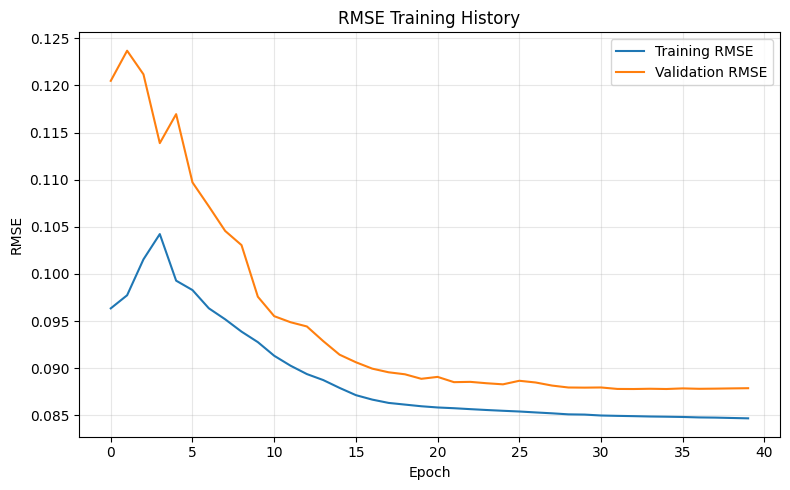

3209/3209 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step

Prediction std    : 0.06950362
Actual std        : 0.11535008
Prediction min/max: 0.035750322 0.92763585
Actual min/max    : 0.0 1.0

Overall Evaluation on Test Set:
  MAE : 2.5564
  RMSE: 3.6264
  R²  : 0.4397

Per Horizon Step Evaluation:
  t+1 (15min) — MAE: 1.9358  RMSE: 3.0142, R²: 0.6130
  t+2 (30min) — MAE: 2.6179  RMSE: 3.6623, R²: 0.4285
  t+3 (45min) — MAE: 2.8046  RMSE: 3.8460, R²: 0.3697
  t+4 (60min) — MAE: 2.8673  RMSE: 3.9132, R²: 0.3476


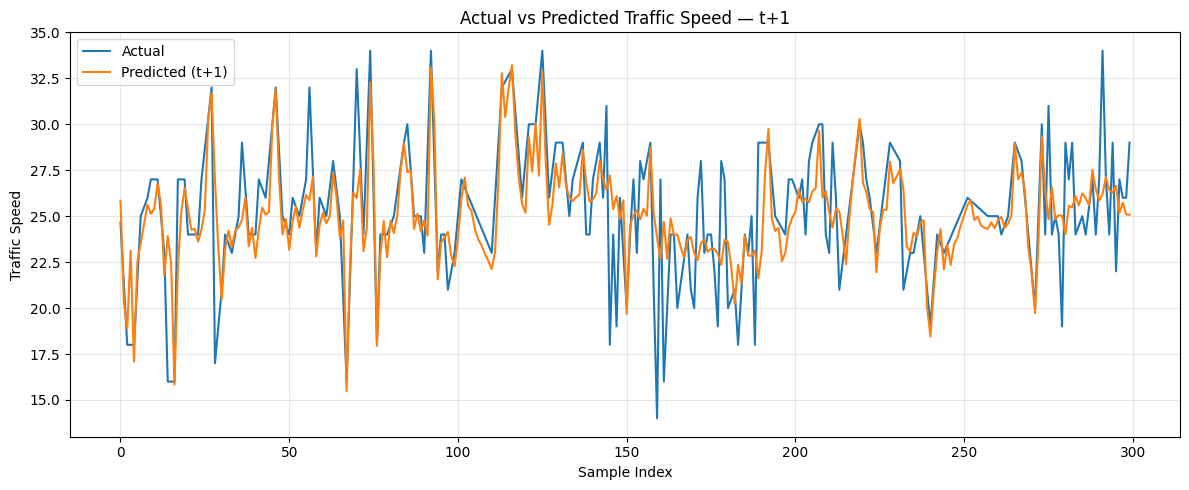

In [ ]:
# 1. Reprodcuability setup
#=========================
import os
os.environ['TF_DETERMINISTIC_OPS'] = '1'      #make TensorFlow operations deterministic (reproducable)

import numpy as np                            #numerical computations and array handling
import matplotlib.pyplot as plt               #plotting graphs and visualization
import tensorflow as tf                       #deep learning framework

from tensorflow.keras.models import Model     #allows me to build a custom neural network architecture which is more flexible than simple sequential models
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Concatenate                #neural network layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint    #training control tools
from tensorflow.keras.optimizers import Adam                                                #optimization algorithm for training
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score               #evaluation metrics

np.random.seed(42)                            #fix NumPy randomness
tf.random.set_seed(42)                        #fix TensorFlow randomness

# 2. VALIDATION SPLIT
# Take last 10% of training sequences with respect to time
#=========================================================
val_size = int(len(X_train) * 0.1)            #take last 10% of training daat for validation
X_val = X_train[-val_size:]                   #validation inputs (last part, time-respecting)
y_val = y_train[-val_size:]                   #validation targets
X_tr  = X_train[:-val_size]                   #remaining training inputs
y_tr  = y_train[:-val_size]                   #remaining training targets

print("Train sequences     :", X_tr.shape)    #training shape
print("Validation sequences:", X_val.shape)   #validation shape
print("Test sequences      :", X_test.shape)  #test shape

# 3. BUILD MODEL
#========================================================
inputs = Input(shape=(X_tr.shape[1], X_tr.shape[2])) #each sample = sequence of 24 steps, each step has multiple features

x = LSTM(128, return_sequences=True)(inputs)         #first LSTM layer with 128 units to learn complex temporal patterns (keeps sequence output)
x = Dropout(0.2)(x)                                  #randomly drop 20% of neurons during training to reduce overfitting

x = LSTM(64)(x)                                      #second LSTM layer with 64 units to compress learned sequence into a smaller representation (outputs final vector)
x = Dropout(0.2)(x)                                  #again drop 20% of neurons to reduce overfitting and prevent model from relying too much on specific neurons

x = Dense(32, activation='relu')(x)                  #dense layer with 32 neurons to transform LSTM output into compact features for prediction

#Per-horizon heads — each horizon learns its own output mapping
t1 = Dense(1, activation='sigmoid', name='t1')(x)    #predict 1 value (t+1), use sigmoid to putput between 0 and 1 to match scaled data
t2 = Dense(1, activation='sigmoid', name='t2')(x)    #predict t+2
t3 = Dense(1, activation='sigmoid', name='t3')(x)    #predict t+3
t4 = Dense(1, activation='sigmoid', name='t4')(x)    #predict t+4

output = Concatenate()([t1, t2, t3, t4])             #combine 4 sperate predictions to get a final output shape of (batch size, 4)

model = Model(inputs, output)                        #build model by connecting the defined input layer to the final 4-step output layer

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)                                                    #adam optimizer with learning rate of 0.001 (controls how fast the model updates its weights)
                                                     #MSE loss to penalize larger prediction errors more strongly and I will track RMSE during training
model.summary()                                      #display model layers, output shapes, and number of trainable parameters

# 4. CALLBACKS
#==============
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        #watch validation loss to detect when the model stops improving

        patience=10,
        #wait 10 epochs before stopping if validation loss does not improve

        restore_best_weights=True,
        #restore weights from the best validation-loss epoch

        verbose=1
        #print callback messages during training
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        #watch validation loss for learning rate adjustment

        factor=0.5,
        #reduce learning rate by half when improvement stops

        patience=5,
        #wait 5 epochs before reducing learning rate

        min_lr=1e-5,
        #do not reduce learning rate below 0.00001

        verbose=1
        #print learnign-rate reduction messages
    ),
    ModelCheckpoint(
        'best_lstm_model.keras',
        #save best model to this file

        monitor='val_loss',
        #choose best model based on validation loss

        save_best_only=True,
        #only save the model when validation loss improves

        verbose=0
        #don't print checkpoint messages
    )
]

# 5. TRAIN
#=========
history = model.fit(
    X_tr, y_tr,
    #train using input sequences and their 4-step speed targets

    validation_data=(X_val, y_val),
    #evaluate on validation data after each epoch

    epochs=40,
    #allow training for up to 40 passes over the training data

    batch_size=256,
    #update weights after processing 256 samples at a time

    callbacks=callbacks,
    #apply early stopping, learning rate reductions, and model saving

    shuffle=False,
    #keep temporal order instead of randomly shuffling sequences

    verbose=1
    #show training progress for each epoch
)

# 6. PLOT TRAINING HISTORY
#=========================
plt.figure(figsize=(8, 5))                                      #create a figure with width 8 and height 5 inches
plt.plot(history.history['rmse'], label='Training RMSE')        #plot training loss recorded after each epoch
plt.plot(history.history['val_rmse'], label='Validation RMSE')  #plot validation loss recorded after each epoch
plt.xlabel('Epoch')                                             #x-axis label
plt.ylabel('RMSE')                                              #y-axis label
plt.title('RMSE Training History')                              #title of plot
plt.legend()                                                    #show legend  (labels for training and validation curves)
plt.grid(True, alpha=0.3)                                       #add light grid lines with 30% transparency
plt.tight_layout()                                              #adjust layout spacing
plt.show()                                                      #display plot

# 7. PREDICT
#============
y_pred_scaled = model.predict(X_test)                           #predict test outputs (result shape = number of test samples, 4 future steps)

print("\nPrediction std    :", y_pred_scaled.std())             #show spread of predicted scaled values
print("Actual std        :", y_test.std())                      #show spread of actual scaled target values
print("Prediction min/max:", y_pred_scaled.min(), y_pred_scaled.max())  #show minimum and maximum predicted scaled values
print("Actual min/max    :", y_test.min(),         y_test.max())        #show minimum and maximum actual scaled target values

# 8. INVERSE TRANSFORM
#=====================
n_samples = y_test.shape[0]                                      #number of test samples

y_test_actual = target_scaler.inverse_transform(
    y_test.reshape(-1, 1)).reshape(n_samples, forecast_horizon)  #convert actual y values from scaled form back to original speed scales, then restore shape (samples, 4)

y_pred_actual = target_scaler.inverse_transform(
    y_pred_scaled.reshape(-1, 1)).reshape(n_samples, forecast_horizon)  #convert predicted values from scaled form back to original speed scale, then restore shape (samples, 4)

# 9. EVALUATE; overall and per horizon step
#===========================================
y_test_flat = y_test_actual.flatten()                           #convert all actual values from (samples, 4) into one long 1D array
y_pred_flat = y_pred_actual.flatten()                           #convert all predicted values from (samples, 4) into one long 1D array

mae  = mean_absolute_error(y_test_flat, y_pred_flat)            #calculate mean absolute predicion error over all horizons
rmse = np.sqrt(mean_squared_error(y_test_flat, y_pred_flat))    #calculate RMSE (larger errors are penalized more strongly)
r2   = r2_score(y_test_flat, y_pred_flat)                       #calculate how much avriance in actual speed is explained by predictions

#display overall evaluation on test set
print("\nOverall Evaluation on Test Set:")
print(f"  MAE : {mae:.4f}")
print(f"  RMSE: {rmse:.4f}")
print(f"  R²  : {r2:.4f}")

#compute and display evaluations per horizon (t+1, t+2, t+3, and t+4)
print("\nPer Horizon Step Evaluation:")
for step in range(forecast_horizon):
    step_mae  = mean_absolute_error(y_test_actual[:, step], y_pred_actual[:, step])
    step_rmse = np.sqrt(mean_squared_error(y_test_actual[:, step], y_pred_actual[:, step]))
    step_r2 = r2_score(y_test_actual[:, step], y_pred_actual[:, step])
    print(f"  t+{step+1} ({(step+1)*15}min) — MAE: {step_mae:.4f}  RMSE: {step_rmse:.4f}, R²: {step_r2:.4f}")

# 10. ACTUAL VS PREDICTED LINE PLOT (first 300 samples, t+1)
#==========================================================
plt.figure(figsize=(12, 5))                                   #create a figure of size 12 by 5 inches
plt.plot(y_test_actual[:300, 0], label='Actual')              #plot actual speeds for first 300 samples at t+1 only (first 15 minutes)
plt.plot(y_pred_actual[:300, 0], label='Predicted (t+1)')     #plot predicted speeds for first 300 samples at t+1 only
plt.xlabel('Sample Index')                                    #x-axis label
plt.ylabel('Traffic Speed')                                   #y-axis label
plt.title('Actual vs Predicted Traffic Speed — t+1')          #title
plt.legend()                                                  #show legend (actual and predicted labels)
plt.grid(True, alpha=0.3)                                     #add light grid lines with 30% transparency
plt.tight_layout()                                            #adjust layout spacing
plt.show()                                                    #display plot
